In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('perrin-freres-monthly-champagne-.csv')

In [3]:
df.head()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [4]:
# Columns name is very long , lets rename it ..

df.columns = ['Month','Sales']
df.head()

,Month,Sales
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [5]:
# Checking Dimensions of Data

df.shape

(107, 2)

In [6]:
# Checking Null Values 

df.isnull().sum()

Month    1
Sales    2
dtype: int64

In [7]:
# Just checking last 5 rows of the Dataset

df.tail()

,Month,Sales
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0
105,NaN,NaN
106,Perrin Freres monthly champagne sales millions...,NaN


In [8]:
# Becuase its 1 in Month and 2 in Sales -> We're gonna remove the entire rows ...

df.drop(106,axis=0,inplace=True) # axis = 0 is becuase we have to remove the row completely in horizontal way...
# inplace = True -> We do this becuase we have to update the data frame as well after dropping the row completely.

In [9]:
df.drop(105,axis=0,inplace=True) # Remeving the 105th row as well

In [10]:
# Checking Datatype of our Data .

df.dtypes

Month     object
Sales    float64
dtype: object

In [11]:
# Month DataType is Object , But it should be Date Time Format . Lets change it to Date-Time

df['Month'] = pd.to_datetime(df['Month'])

In [12]:
df.dtypes

Month    datetime64[ns]
Sales           float64
dtype: object

In [13]:
# No if you see in Dataset , These 0,1,2,3,4 are indexes . But in Machine Learning these will be Numbers and According to Time Series - We want Month to be the Index

df.set_index('Month',inplace=True)

In [14]:
df.head()

,Sales
Month,
1964-01-01,2815.0
1964-02-01,2672.0
1964-03-01,2755.0
1964-04-01,2721.0
1964-05-01,2946.0


In [15]:
# Lets see some statistics of this Dataset.
df.describe() # This is Descriptive Statistics .

,Sales
count,105.000000
mean,4761.152381
std,2553.502601
min,1413.000000
25%,3113.000000
50%,4217.000000
75%,5221.000000
max,13916.000000


🔹 What .describe() is REALLY doing

It’s giving you a statistical summary of your column (Sales).

Think of it like:

“Give me a quick snapshot of how this data behaves”

🔹 Your Output (Simplified)
Metric	Value
count	105
mean	4761
std	2553
min	1413
25%	3113
50% (median)	4217
75%	5221
max	13916
🔥 Now let's ACTUALLY analyze it like a Data Scientist
🔸 1. Count → Data size

👉 105

You have 105 data points
If this is time series → maybe 105 days / weeks

✔ What to say:

“Dataset contains 105 observations, sufficient for initial time series modeling but relatively small for complex models.”

🔸 2. Mean vs Median → Skewness
Mean = 4761
Median = 4217

👉 Mean > Median → Right Skewed

💡 Interpretation:

Some large values are pulling the average up

✔ What to say:

“The distribution is positively skewed, indicating presence of higher sales spikes.”

🔸 3. Min & Max → Range
Min = 1413
Max = 13916

👉 Huge difference (~10x)

💡 Interpretation:

Sales are highly variable
Possible:
Outliers
Seasonal spikes
Promotions

✔ What to say:

“Wide range suggests strong variability and potential outliers or peak demand periods.”

🔸 4. Quartiles → Distribution Spread
25% = 3113
50% = 4217
75% = 5221

👉 Most values lie between:
3113 → 5221

💡 Interpretation:

Normal sales are in this range
Anything above ~5221 might be high sales period

✔ What to say:

“Majority of sales fall within interquartile range (3113–5221), indicating stable baseline demand.”

🔸 5. Standard Deviation → Volatility
Std = 2553

👉 Compare with mean (4761)

👉 Std is ~50% of mean → VERY HIGH variability

💡 Interpretation:

Data is not stable
Strong fluctuations

✔ What to say:

“High standard deviation indicates significant fluctuations, suggesting non-stationarity in the time series.”

🔥 What YOU should conclude overall

If I were reviewing your project, I’d expect something like:

“The sales data exhibits high variability with a wide range (1413–13916) and a relatively high standard deviation (~2553), indicating fluctuating demand. The mean being higher than the median suggests positive skewness, likely due to occasional sales spikes. Most values lie within the interquartile range (3113–5221), representing baseline sales levels.”

<Axes: xlabel='Month'>

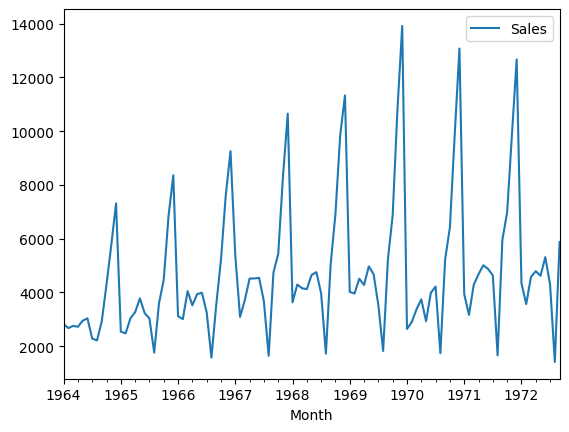

In [16]:
# Now understanding the data more , by plotting .

df.plot()

In [17]:
# We can figure out Seasonality in our Data. 
# Christmas -> Sales up. 

In [18]:
# Now we have to perform statstical test for stationary

# So for that we perform :-
    # adfuller test -> its called augmented dicifuller test.
    # adfuller test will return us p-value
    # if p-value is < 0.05 we can say that our data is "non-stationary"

In [19]:
# To perform we have statsmodel library.

import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\shiva\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [20]:
from statsmodels.tsa.stattools import adfuller

In [21]:
adfuller(df['Sales'])

(np.float64(-1.8335930563276195),
 np.float64(0.3639157716602467),
 11,
 93,
 {'1%': np.float64(-3.502704609582561),
  '5%': np.float64(-2.8931578098779522),
  '10%': np.float64(-2.583636712914788)},
 np.float64(1478.4633060594724))

In [22]:
# Hyphothesis Testing . 
# We have basically 2 types of Hyphothesis . 

# 1. Null Hyphothesis -> Which says your data is not-stationary.

# 2. Alternate Hyphothesis -> Which says data is stationary. 


def adfuller_test(sales):
    result = adfuller(sales)

    labels = ['ADF Test Statistics', 'P-Value','Lags Used','Number of obs used']

    for value,label in zip(result,labels):
        print('{} : {} '.format(label,value))
    if result[1]<=0.05:
        print('Strong Evidence against Null Hypothesis, Reject the Null Hypo & Data is Stationary')
    else:
        print('Weak Evidence against Null Hypothesis, Accept the Null Hypo & Data is Non - Stationary')

In [23]:
adfuller_test(df['Sales'])

ADF Test Statistics : -1.8335930563276195 
P-Value : 0.3639157716602467 
Lags Used : 11 
Number of obs used : 93 
Weak Evidence against Null Hypothesis, Accept the Null Hypo & Data is Non - Stationary


Firstly we have to make sure , Data should be Stationary.

In [24]:
# How to make your data ' Stationary using concept of Diffrencing.

In data science, diffrencing and shifting are techniques used primarily to manipulate time-series data or prepare data for modeling by managing trends, seasonality, and dependency on previous time steps

In [25]:
df['Sales'].shift(1)

Month
1964-01-01       NaN
1964-02-01    2815.0
1964-03-01    2672.0
1964-04-01    2755.0
1964-05-01    2721.0
               ...  
1972-05-01    4788.0
1972-06-01    4618.0
1972-07-01    5312.0
1972-08-01    4298.0
1972-09-01    1413.0
Name: Sales, Length: 105, dtype: float64

In [26]:
df['Sales first diff.'] = df['Sales'] - df['Sales'].shift(1)

In [27]:
df.head()

,Sales,Sales first diff.
Month,,
1964-01-01,2815.0,NaN
1964-02-01,2672.0,-143.0
1964-03-01,2755.0,83.0
1964-04-01,2721.0,-34.0
1964-05-01,2946.0,225.0


In [28]:
# We put shift(12) cuz its Seasonal Difference .  
df['Seasonal first diff.'] = df['Sales'] - df['Sales'].shift(12)

In [29]:
df.head()

,Sales,Sales first diff.,Seasonal first diff.
Month,,,
1964-01-01,2815.0,NaN,NaN
1964-02-01,2672.0,-143.0,NaN
1964-03-01,2755.0,83.0,NaN
1964-04-01,2721.0,-34.0,NaN
1964-05-01,2946.0,225.0,NaN


In [30]:
# Now we if 'Seasonal first diff.' has a Stationary trend or not ..

adfuller_test(df['Seasonal first diff.'].dropna())

ADF Test Statistics : -7.626619157213166 
P-Value : 2.0605796968136632e-11 
Lags Used : 0 
Number of obs used : 92 
Strong Evidence against Null Hypothesis, Reject the Null Hypo & Data is Stationary


<Axes: xlabel='Month'>

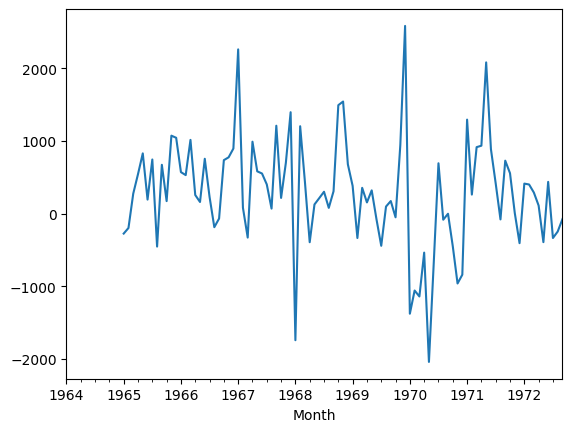

In [31]:
df['Seasonal first diff.'].plot()

APPLYING ARIMA

In [32]:
# What is Auto-Arima 

# It is used 'Automated ML Model of Arima'

# In this , We don't have to set manually or find out all the values. It will be automated.


In [33]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
#Autocorrelation(plot_acf),Partial Autocorrelation(plot_pacf)

In [34]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [35]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\shiva\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


To calculate Arima -> We need p-value, d-value, q-value.

    To calculate p-value -> We have pacf graph.
    To calculate q-value -> We have acf graph.
        d is calculated by differencing.
    

In [36]:
import matplotlib.pyplot as plt

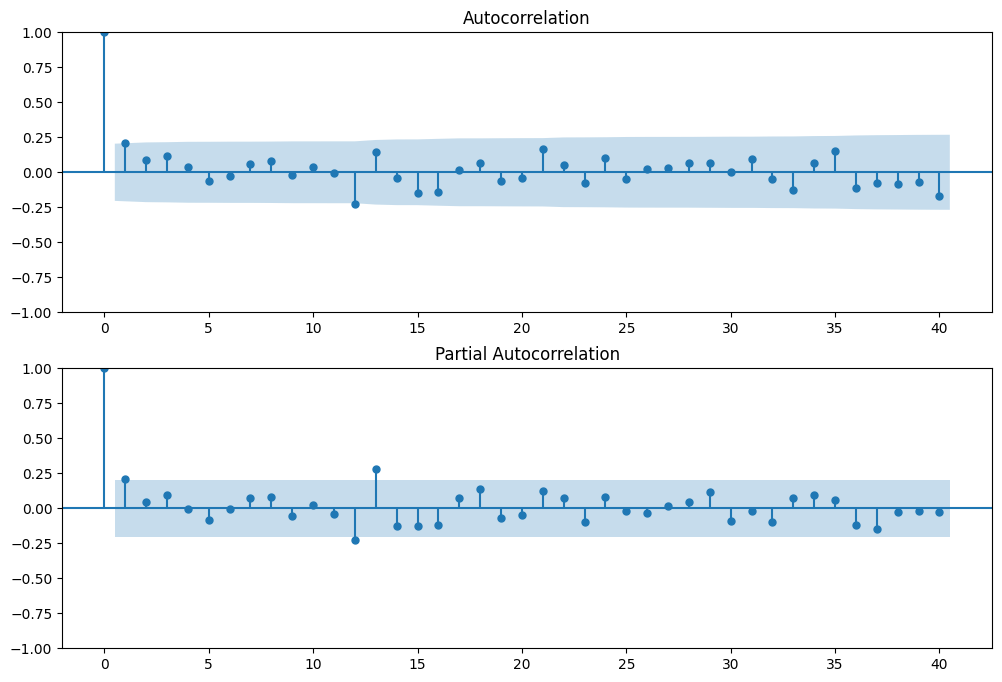

In [39]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = plot_acf(df['Seasonal first diff.'].iloc[13:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(df['Seasonal first diff.'].iloc[13:],lags=40,ax=ax2)

In [43]:
from statsmodels.tsa.arima.model import ARIMA

In [44]:
# Initilize ARIMA

model = ARIMA(df['Sales'],order=(1,1,1))

C:\Users\shiva\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [45]:
model = model.fit()

In [46]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  105
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -952.814
Date:                Tue, 05 May 2026   AIC                           1911.627
Time:                        23:50:10   BIC                           1919.560
Sample:                    01-01-1964   HQIC                          1914.841
                         - 09-01-1972                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4545      0.114      3.999      0.000       0.232       0.677
ma.L1         -0.9666      0.056    -17.316      0.000      -1.076      -0.857
sigma2      5.226e+06   6.17e+05      8.473      0.000    4.02e+06    6.43e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.91   Jarque-Bera (JB):                 2.59
Prob(Q):                              0.34   Prob(JB):                         0.27
Heteroskedasticity (H):               3.40   Skew:                             0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [47]:
# Now we want to do some kind of prediction from this ARIMA Model ..

df['forecast'] = model.predict(start=90,end=103,dynamic=True)

In [48]:
df.tail(20)

,Sales,Sales first diff.,Seasonal first diff.,forecast
Month,,,,
1971-02-01,3162.0,-772.0,263.0,NaN
1971-03-01,4286.0,1124.0,916.0,NaN
1971-04-01,4676.0,390.0,936.0,NaN
1971-05-01,5010.0,334.0,2083.0,NaN
1971-06-01,4874.0,-136.0,888.0,NaN
1971-07-01,4633.0,-241.0,416.0,4977.053438
1971-08-01,1659.0,-2974.0,-79.0,5023.890764
1971-09-01,5951.0,4292.0,730.0,5045.178119
1971-10-01,6981.0,1030.0,557.0,5054.853126


<Axes: xlabel='Month'>

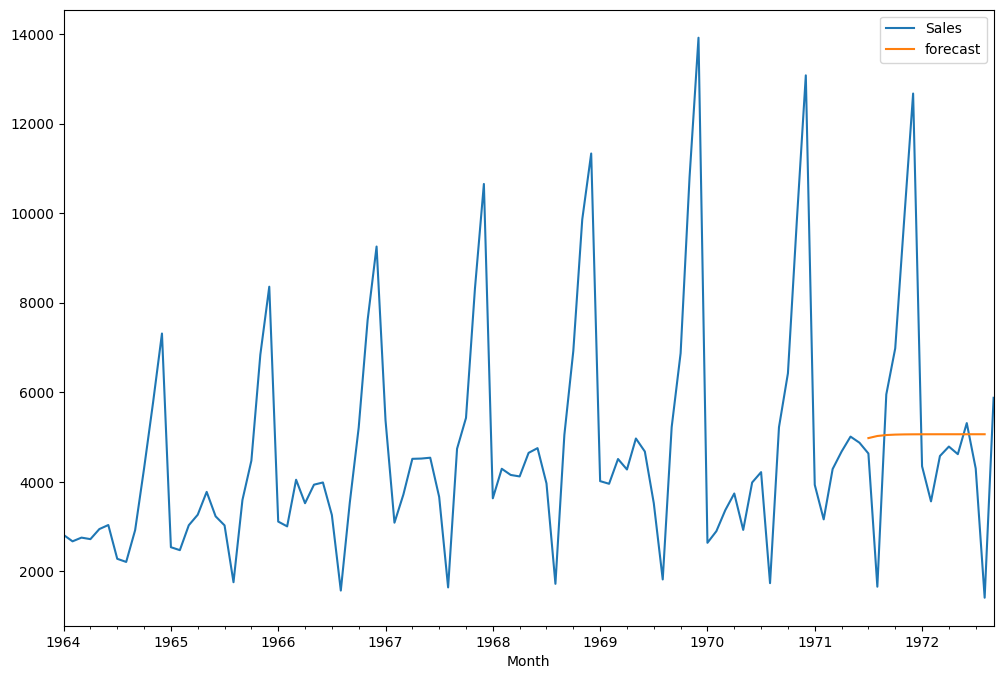

In [51]:
# Plotting actual values vs broadcasted values.

df[['Sales','forecast']].plot(figsize=(12,8))

In [52]:
# This is a Seasonal Data - ARIMA is not Suitable for this type of Predicition or Problem.

In [53]:
# For Seasonal Data -> We have SARIMAX = Seasonal ARIMA .

In [55]:
import statsmodels.api as sm

In [60]:
# This is how you apply SARIMAX . In Seasonal Order we pass shift value that we have applied.
# Step 1: Create model
model = sm.tsa.statespace.SARIMAX(
    df['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

C:\Users\shiva\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [61]:
# Step 2: Fit model
results = model.fit()

In [62]:
# Predicting 

df['forecast_SARIMAX'] = results.predict(start=90,end=103,dynamic=True)

In [63]:
df.tail(20)

,Sales,Sales first diff.,Seasonal first diff.,forecast,forecast_SARIMAX
Month,,,,,
1971-02-01,3162.0,-772.0,263.0,NaN,NaN
1971-03-01,4286.0,1124.0,916.0,NaN,NaN
1971-04-01,4676.0,390.0,936.0,NaN,NaN
1971-05-01,5010.0,334.0,2083.0,NaN,NaN
1971-06-01,4874.0,-136.0,888.0,NaN,NaN
1971-07-01,4633.0,-241.0,416.0,4977.053438,4437.324514
1971-08-01,1659.0,-2974.0,-79.0,5023.890764,2050.747540
1971-09-01,5951.0,4292.0,730.0,5045.178119,5493.376471
1971-10-01,6981.0,1030.0,557.0,5054.853126,6752.038993


<Axes: xlabel='Month'>

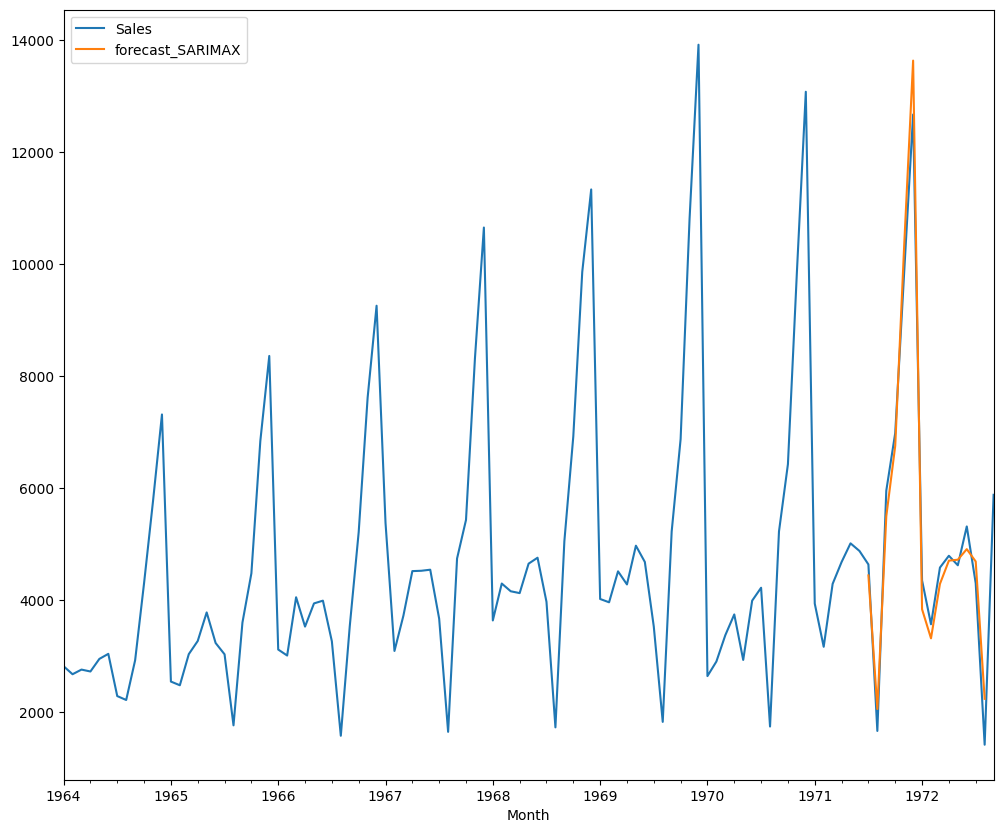

In [64]:
# Checking the difference between my forecasted data and actual data.

df[['Sales','forecast_SARIMAX']].plot(figsize=(12,10))

In [65]:
# Look how well SARIMAX performed , cuz its seasonal data.

Now we will create an additional dataset & will do predicition over there. 

In [66]:
# Create an additional dataset

# Will use dateoffset for it .


In [67]:
from pandas.tseries.offsets import DateOffset

In [70]:
df.index[-1]

Timestamp('1972-09-01 00:00:00')

In [69]:
# Creating an additional data for 24 months

future_dates = [df.index[-1] + DateOffset(months=x) for x in range(0,24)]

In [71]:
future_dataset = pd.DataFrame(index=future_dates[1:],columns = df.columns)

In [72]:
future_dataset.tail()

,Sales,Sales first diff.,Seasonal first diff.,forecast,forecast_SARIMAX
1974-04-01,NaN,NaN,NaN,NaN,NaN
1974-05-01,NaN,NaN,NaN,NaN,NaN
1974-06-01,NaN,NaN,NaN,NaN,NaN
1974-07-01,NaN,NaN,NaN,NaN,NaN
1974-08-01,NaN,NaN,NaN,NaN,NaN


In [75]:
future_df = pd.concat([df,future_dataset])

C:\Users\shiva\AppData\Local\Temp\ipykernel_22572\3142971550.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  future_df = pd.concat([df,future_dataset])


In [76]:
future_df.shape

(128, 5)

In [78]:
future_df['forecast_SARIMAX'] = results.predict(start=104,end=124,dynamic=True)

<Axes: >

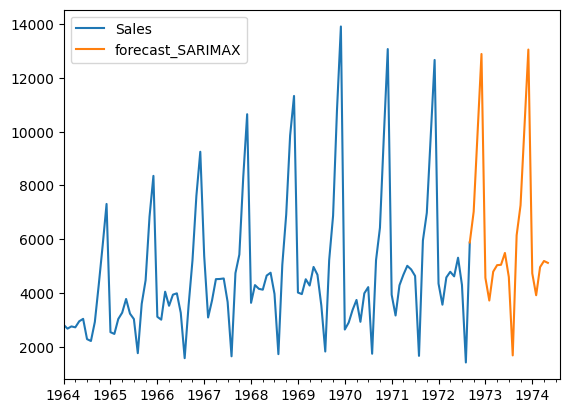

In [79]:
future_df[['Sales','forecast_SARIMAX']].plot(fig=(12,8))